### Random Forest Regression using Original Features

#### Model Overview

Random Forest is an ensemble learning method that combines predictions from multiple decision trees. For regression, the final prediction is obtained by averaging the predictions from the individual trees.

It can capture nonlinear relationships and interactions without requiring explicit polynomial or interaction terms.

This model uses the same original feature set and train-test split as the baseline Multiple Linear Regression model.

#### 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    cross_validate,
    KFold,
    train_test_split,
    cross_val_score
)
from sklearn.inspection import permutation_importance

### 2. Load the processed dataset

In [69]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

data_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "crop_yield_cleaned.csv"
)
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Figures will be saved to: {FIGURES_DIR}")
data = pd.read_csv(data_path)

print(data.shape)
data.head()

Figures will be saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/reports/figures
(999, 8)


,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


### 3. Define the original faetures and target

In [3]:
original_features = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

target = "yield"

X = data[original_features].copy()
y = data[target].copy()

#### 4. Recreate the common train-test split
Same split convention as the baseline model: **20% test size, random_state=42**.

In [6]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

In [7]:
print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

print(X_train.columns.tolist())

Training features: (799, 7)
Test features: (200, 7)
Training target: (799,)
Test target: (200,)
['crop_type', 'rainfall', 'temperature', 'fertilizer', 'nitrogen', 'phosphorus', 'potassium']


### 5. Define the preprocessing step

In [8]:
categorical_features = ["crop_type"]

numerical_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

---
<a name="6.-Model-Construction"></a>
### 6. Model Construction

### 6.1. Construct the pipeline 

In [9]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

#### 7. Tune Model - Define the hyperparameter grid

In [17]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

### 8. Run GridSearchCV

In [18]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricev

### 9. Retrieve the best model

In [20]:
print("Best parameters:")
print(rf_grid.best_params_)

best_cv_rmse = -rf_grid.best_score_

print(
    f"Best training CV RMSE: "
    f"{best_cv_rmse:.4f}"
)

rf_best = rf_grid.best_estimator_

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best training CV RMSE: 2.7130


In [21]:
rf_best = rf_grid.best_estimator_
rf_best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['crop_type','rainfall','temperature',...,'nitrogen','phosphorus', 'potassium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

---
<a name="7.-Model-Results-&-Evaluation"></a>
### 7. Model Results & Evaluation

#### 7.1 Predict on Train and Test Sets

In [22]:
pred_train = rf_best.predict(X_train)
pred_test = rf_best.predict(X_test)

#### 7.2 Model Performance metrics

In [23]:
train_mae = mean_absolute_error(y_train, pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
train_r2 = r2_score(y_train, pred_train)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_r2 = r2_score(y_test, pred_test)

print(f'Train  -> MAE: {train_mae:.3f} | RMSE: {train_rmse:.3f} | R2: {train_r2:.3f}')
print(f'Test   -> MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f} | R2: {test_r2:.3f}')

Train  -> MAE: 2.113 | RMSE: 2.491 | R2: 0.190
Test   -> MAE: 2.546 | RMSE: 2.939 | R2: -0.003


#### 7.3 Five-Fold Cross-Validation

In [25]:
kf5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse = -cross_val_score(
    rf_best,
    X,
    y,
    cv=kf5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print(
    f"CV RMSE mean: {cv_rmse.mean():.3f} | "
    f"CV RMSE std: {cv_rmse.std():.3f}"
)

CV RMSE mean: 2.761 | CV RMSE std: 0.131


### 8. Impact Analysis

### 8.1 Permutation Importance Analysis

In [49]:
# Extract the fitted preprocessing step and Random Forest model
fitted_preprocessor = rf_best.named_steps["preprocessor"]
fitted_rf = rf_best.named_steps["model"]

# Obtain the feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Match each transformed feature with its importance value
importances = pd.Series(
    fitted_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Clean the prefixes added by ColumnTransformer
importances.index = (
    importances.index
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

display(
    importances
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
    .round(4)
)

,feature,importance
0,temperature,0.2035
1,rainfall,0.2003
2,fertilizer,0.1607
3,nitrogen,0.1281
4,potassium,0.1166
5,phosphorus,0.1155
6,crop_type_Wheat,0.0232
7,crop_type_Rice,0.0159
8,crop_type_Soybean,0.0133
9,crop_type_Corn,0.0115


In [50]:
rf_permutation = permutation_importance(
    estimator=rf_best,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": rf_permutation.importances_mean,
    "importance_std": rf_permutation.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(permutation_table.round(4))

,feature,importance_mean,importance_std
0,rainfall,0.0190,0.0080
1,temperature,0.0181,0.0144
2,phosphorus,0.0058,0.0101
3,nitrogen,0.0000,0.0068
4,fertilizer,-0.0002,0.0121
5,potassium,-0.0083,0.0107
6,crop_type,-0.0148,0.0055


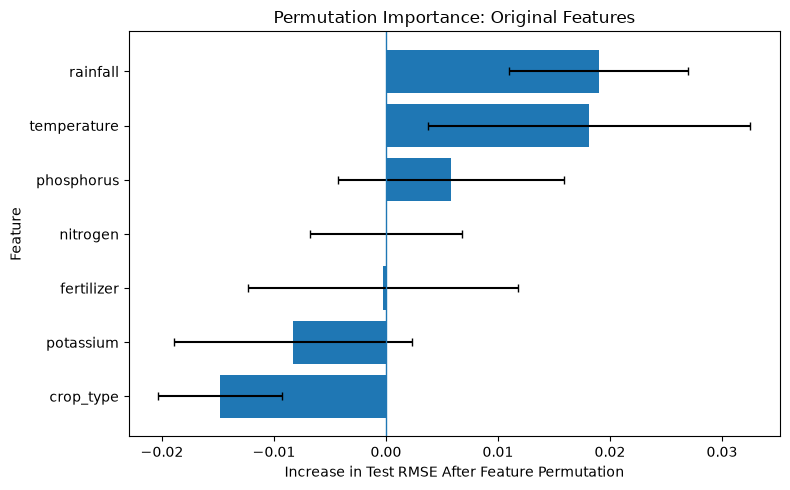

In [70]:
plot_data = permutation_table.sort_values(
    "importance_mean",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"],
    capsize=3
)

ax.axvline(
    x=0,
    linewidth=1
)

ax.set_xlabel("Increase in Test RMSE After Feature Permutation")
ax.set_ylabel("Feature")
ax.set_title(
    "Permutation Importance: Original Features"
)

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "rf_original_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Permutation importance was first used to identify the predictors on which the Random Forest relied most heavily. Partial dependence analysis was then used to examine how the model’s predicted crop yield changed across the observed values of each predictor. These results describe relationships learned by the fitted model and should not be interpreted as causal effects.

### 8.2 Partial Dependence Analysis

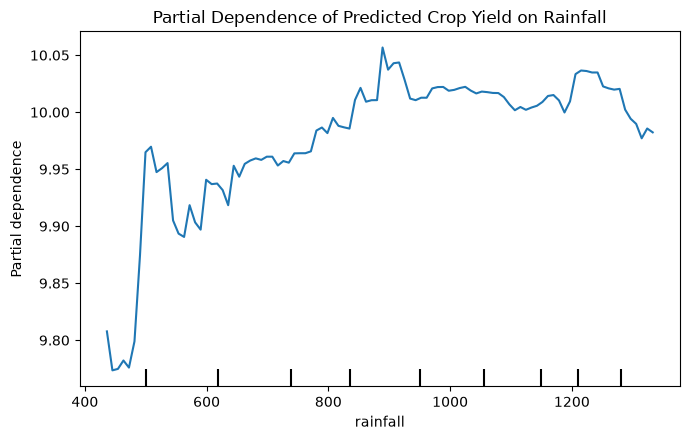

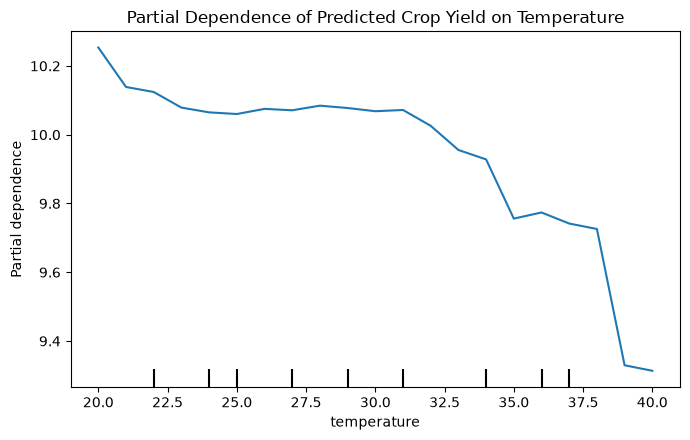

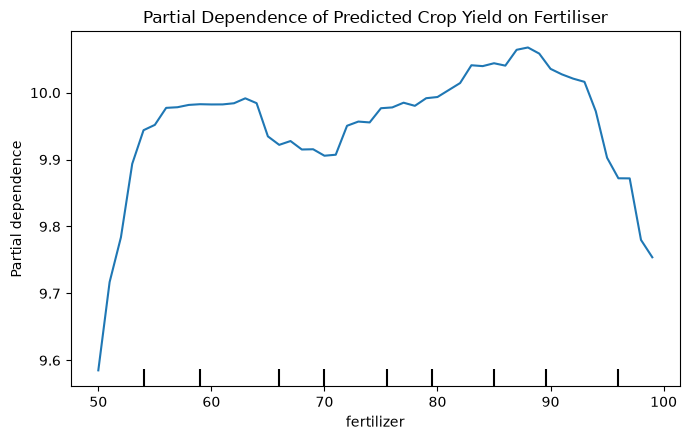

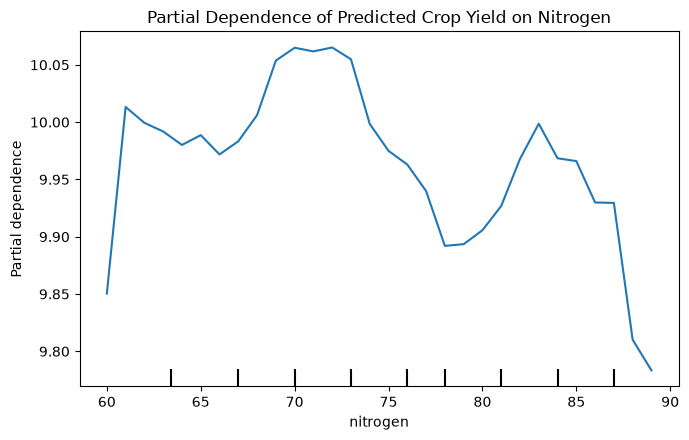

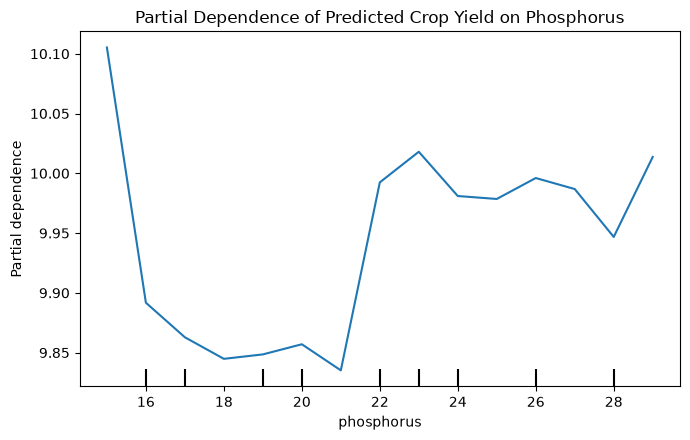

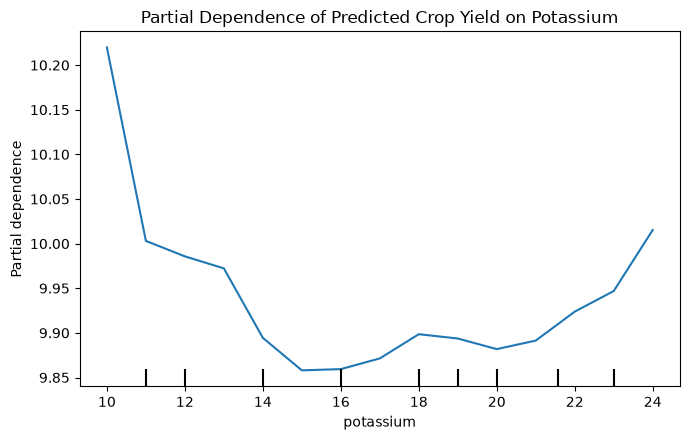

In [71]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

numeric_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

display_names = {
    "rainfall": "Rainfall",
    "temperature": "Temperature",
    "fertilizer": "Fertiliser",
    "nitrogen": "Nitrogen",
    "phosphorus": "Phosphorus",
    "potassium": "Potassium"
}

# Create a copy specifically for partial dependence
X_test_pdp = X_test.copy()

# Convert numerical columns to float
X_test_pdp[numeric_features] = (
    X_test_pdp[numeric_features]
    .astype(float)
)

for feature in numeric_features:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    PartialDependenceDisplay.from_estimator(
        estimator=rf_best,
        X=X_test_pdp,
        features=[feature],
        ax=ax,
        kind="average"
    )

    ax.set_title(
        f"Partial Dependence of Predicted Crop Yield on "
        f"{display_names[feature]}"
    )

    plt.tight_layout()
    fig.savefig(
    FIGURES_DIR / "rf_original_pdp_impact.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

### 8.3 Estimated Impact of Crop Type
Since crop_type is categorical, assess its modelled impact by setting every test observation to each crop type in turn, predicting yield, and comparing the average prediction

In [60]:
# Identify the crop types in the test data
crop_types = sorted(X_test["crop_type"].unique())

crop_impact = []

for crop in crop_types:
    X_modified = X_test.copy()

    # Set all observations to the same crop type
    X_modified["crop_type"] = crop

    # Predict average yield under that crop type
    mean_predicted_yield = rf_best.predict(X_modified).mean()

    crop_impact.append({
        "crop_type": crop,
        "mean_predicted_yield": mean_predicted_yield
    })

crop_impact = (
    pd.DataFrame(crop_impact)
    .sort_values(
        "mean_predicted_yield",
        ascending=True
    )
    .reset_index(drop=True)
)

display(crop_impact.round(3))

,crop_type,mean_predicted_yield
0,Wheat,9.776
1,Sorghum,9.940
2,Barley,9.971
3,Corn,9.987
4,Soybean,10.032
5,Rice,10.053


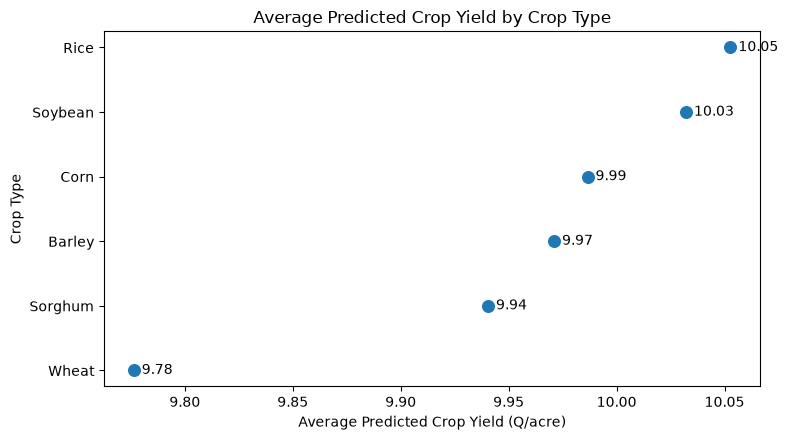

In [72]:
crop_plot = crop_impact.sort_values(
    "mean_predicted_yield",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.scatter(
    crop_plot["mean_predicted_yield"],
    crop_plot["crop_type"],
    s=70
)

for _, row in crop_plot.iterrows():
    ax.text(
        row["mean_predicted_yield"],
        row["crop_type"],
        f'  {row["mean_predicted_yield"]:.2f}',
        va="center"
    )

ax.set_xlabel("Average Predicted Crop Yield (Q/acre)")
ax.set_ylabel("Crop Type")
ax.set_title(
    "Average Predicted Crop Yield by Crop Type"
)

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "rf_original_crop_type_impact.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

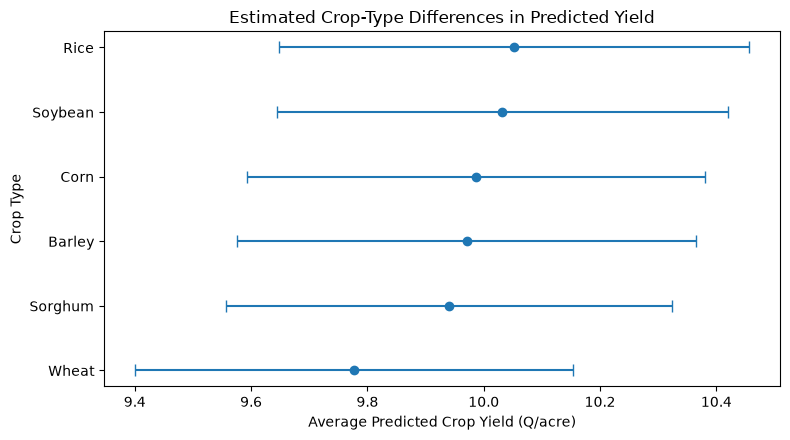

In [75]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    crop_impact_detailed["mean_predicted_yield"],
    crop_impact_detailed["crop_type"],
    xerr=crop_impact_detailed["std_predicted_yield"],
    fmt="o",
    capsize=4
)

ax.set_xlabel("Average Predicted Crop Yield (Q/acre)")
ax.set_ylabel("Crop Type")
ax.set_title(
    "Estimated Crop-Type Differences in Predicted Yield"
)

plt.tight_layout()
plt.show()

### 8.4 Impact Analysis Summary

Permutation importance identified rainfall and temperature as the most useful predictors relative to the other available features. Partial dependence analysis showed the non-linear patterns learned by the model, while the crop-type analysis indicated only small differences in average predicted yield across crop categories. However, because the model recorded a negative test R
2
, these patterns should be viewed as model-based associations rather than reliable causal effects or strong agronomic conclusions.

### 9. Random Forest Summary

In [67]:
rf_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Train": [2.113, 2.491, 0.190],
    "Test": [2.546, 2.939, -0.003]
})

display(rf_summary)

,Metric,Train,Test
0,MAE,2.113,2.546
1,RMSE,2.491,2.939
2,R²,0.190,-0.003


The tuned Random Forest achieved a training MAE of 2.113 and a test MAE of 2.546, with corresponding RMSE values of 2.491 and 2.939. The training R
2
 of 0.190 indicates that the model explained approximately 19% of the variation in crop yield within the training data. However, the test R
2
 of −0.003 indicates that the model performed marginally worse than predicting the average yield for all test observations.

The difference between the training and test results suggests that the Random Forest captured some patterns in the training data that did not generalise to unseen observations. Overall, the original feature set provided limited predictive information for crop yield, and the model’s impact-analysis findings should therefore be interpreted cautiously.